#**Maestría en Inteligencia Artificial Aplicada**
##**Curso: Procesamiento de Lenguaje Natural (NLP)**
###Tecnológico de Monterrey
###Prof Luis Eduardo Falcón Morales

## **Adtividad de la Semana: Análisis de Sentimiento**

###**Pre-procesamiento, Matrices Documeto-Término (DTM) y TF-IDF.**

* **Nombre:** Joel Becerril

* **matrícula:** A01797427

En esta actividad deberás utilizar los datos de tres archivos que se encuentran en el repositorio de la UCI que te indico más abajo:

*   **amazon_cells_labelled.txt** Contiene 1000 registros de comentarios de usuarios que adquirieron un producto a través de la plataforma de Amazon.

*   **imdb_labelled.txt** Contiene 1000 registros de comentarios que dejaron usuarios sobre palículas y series en la plataforma de IMBD.

*   **yelp_labelled.txt** Contiene 1000 comentarios de usuarios sobre servicios de comida dejados en l aplataforma de Yelp.

La información del problema y de los archivos están basados en el repositorio de la UCI. Descarga los archivos de la suguiente liga:

https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences



In [1]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string
import matplotlib.pyplot as plt

In [2]:
nltk.download('punkt')        # tokenizador por enunciados (modelo no supervisado)
nltk.download('punkt_tab')    # recurso requerido por versiones recientes de NLTK
nltk.download('stopwords')    # acceso a stopwords en varios idiomas

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/joelbecerril/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/joelbecerril/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/joelbecerril/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

##**Pregunta - 1:**



* ### Comenta qué significa en este problema un Falso-Negativo y un Falso-Positivo. ¿Qué implicaciones podrían tener cada uno de estos errores?

* ### ¿Cuál tipo de error se podría considerar más grave en el contexto del problema? ¿O serían igual de importantes cada uno? Justifica tu respuesta.

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 1:**

En este problema de análisis de sentimiento, cada comentario se clasifica como **positivo (1)** o **negativo (0)**.

**Falso Positivo (FP):** El modelo predice que un comentario es *positivo*, pero en realidad es *negativo*. Por ejemplo, clasificar una reseña crítica de un producto como favorable. En un contexto empresarial, esto llevaría a ignorar señales de alerta sobre la insatisfacción de clientes.

**Falso Negativo (FN):** El modelo predice que un comentario es *negativo*, pero en realidad es *positivo*. Por ejemplo, marcar como negativa una reseña elogiosa. Esto podría llevar a ignorar feedback valioso o descartar clientes satisfechos.

**¿Cuál es más grave?** En este problema ambos errores tienen un costo similar, ya que el dataset está balanceado (50% positivos / 50% negativos) y el objetivo es entender la opinión general de los usuarios. Sin embargo, en aplicaciones donde el objetivo es detectar quejas o problemas (monitoreo de calidad), el **Falso Negativo sería más grave**, ya que dejaríamos pasar comentarios negativos sin atención. En contraste, si el modelo se usa para filtrar contenido ofensivo o fraudulento, el **Falso Positivo sería más dañino**, pues bloquearíamos comentarios legítimos.

En conclusión, la gravedad relativa depende del caso de uso específico. Para este ejercicio general de clasificación de sentimiento, consideramos ambos errores igualmente importantes.

##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

Stopwords:

Como en un problema de análisis de sentimiento solo se desea determinar si un comentario es una reseña positivas o una reseña negativa, pudiera ser importante considerar los conectivos "negativos". Como dichos conectivos están incluidos de manera predeterminada en la lista de "stopwords" de la librería NLTK, los vamos a excluir de dicha lista, para que sí sean parte del vocabulario que estaremos analizando.

A la nueva lista de stopwords la llamaremos **mystopwords**.

In [3]:
# Veamos la lista de stopwords que se incluyen de manera predeterminada la suite de librerías de NLTK:

print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [4]:
# Consideremos la siguiente lista de palabras asociada a negaciones en inglés:

negwords = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

# Y las excluimos de las stopwords:
mystopwords = [ w for w in stopwords.words('english') if w not in negwords]


print("Total de stopwords en la lista original de NLTK: %d" % len(stopwords.words('english')))
print("Total de sotpwords excluyendo los conectivos negativos: %d\n" % len(mystopwords))

# Nuestra nueva lista:
print(mystopwords)

Total de stopwords en la lista original de NLTK: 198
Total de sotpwords excluyendo los conectivos negativos: 158

['a', 'about', 'above', 'after', 'again', 'against', 'all', 'am', 'an', 'and', 'any', 'are', 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'd', 'did', 'do', 'does', 'doing', 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'has', 'have', 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'more', 'most', 'my', 'myself', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'she', "she'd", "she'll", "she's", 'should', "should've", 'so', 'some', 'such', 't', 'than', 'that', "that'll", 'the', 'their', 'theirs', 'them', 'themselves', 'th

###**Cargamos los datos del problema:**

In [5]:
dfa = pd.read_csv('sentiment labelled sentences/amazon_cells_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')
dfi = pd.read_csv('sentiment labelled sentences/imdb_labelled.txt', delimiter='\t', names=['review','label'], header=None, encoding='utf-8')
dfy = pd.read_csv('sentiment labelled sentences/yelp_labelled.txt', sep='\t', names=['review','label'], header=None, encoding='utf-8')

print('Total de registros de Amazon:',dfa.shape)
print('Total de registros de IMBD:',dfi.shape)
print('Total de registros de Yelp:',dfy.shape)

Total de registros de Amazon: (1000, 2)
Total de registros de IMBD: (748, 2)
Total de registros de Yelp: (1000, 2)


La salida anterior esperada es la siguiente:

Total de registros de Amazon: (1000, 2)

Total de registros de IMBD: (748, 2)

Total de registros de Yelp: (1000, 2)

In [6]:
dfa.head()     # Cada uno de estos data frame está formado de dos columnas,
               # uno con los comentarios (review) y otro con la etiqueta (label).
               # Por ejemplo, mostremos a continuación los primeros comentarios
               # y etiquetas del archivo de Amazon:

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


Sin embargo, observa que los registros de IMBD no son los 1000 que se indican en la documentación de estos datos, sino 748.

En realidad no son datos perdidos, sino que varios de ellos fueron capturados errónamente como uno solo. En ocasiones, la gran cantidad de caracteres especiales que existen actualmente pueden generar errores de este tipo.

Por ejemplo, observa la salida siguiente y cómo el registro de índice 19 tiene una gran cantidad de registros conjuntados como uno solo.



In [7]:
dfi.values.tolist()[17:21]

[["I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.  ",
  1],
 ['It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.  ',
  1],
 [' The structure of this film is easily the most tightly constructed in the history of cinema.  \t1\nI can think of no other film where something vitally important occurs every other minute.  \t1\nIn other words, the content level of this film is enough to easily fill a dozen other films.  \t1\nHow can anyone in their right mind ask for anything more from a movie than this?  \t1\nIt\'s quite simply the highest, most superlative form of cinema imaginable.  \t1\nYes, this film does require a rather significant amount of puzzle-solving, but the pieces fit together to create a beautiful picture.  \t1\nThis short film certainly pulls no punches.  \t0\nGraphics is far from the best part of the game.  \t0\nThis is

Además, se observa que cada comentario (review) debe estar separado de su evaluación (label) por un tabulador "\t" y después separado del siguiente registro por un salto de línea "\n".

Usaremos esta información para separar de manera adecuada estos registros del conjunto de IMBD.

##**Pregunta - 2:**

En este ejercicio deberás corregir este problema que tienen los comentarios de IMBD, del cual se registran 748 comentarios, cuando deben ser 1000.

Como cada DataFrame debe estar formado por 2 columnas (el comentario y la etiqueta de la evaluación), en algunas ocasiones el valor numérico de la etiqueta se toma como parte del comentario y esto empieza a generar dichos errores.

El problema se podrá resolver de varias formas. Realiza una inspección de dichos comentarios y plantea una forma de resolver este problema para obtener nuevamente los 1000 comentarios de manera explícita en el DataFrame de IMBD, dfi.

Al nuevo DataFrame que contenga de manera correcta los 1000 comentarios con sus dos columnas (el de comentatios y el de etiquetas), llamarlo "newdfi".







In [8]:
newdfi = []     # lista de salida que deberá tener los 1000 registros ya debidamente separados.

################################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 2:

# Leemos el archivo crudo como texto plano para poder separar correctamente
# los registros que quedaron concatenados en el DataFrame original.
with open('sentiment labelled sentences/imdb_labelled.txt', 'r', encoding='utf-8') as f:
    raw = f.read()

# Cada registro tiene el formato: texto \t etiqueta(0 o 1)
# Con regex extraemos todos los pares sin importar saltos de línea internos en el texto.
matches = re.findall(r'([^\t]+)\t([01])', raw)
newdfi = [(text.strip(), int(label)) for text, label in matches]

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
################################################################################

print('Total de comentarios de la lista errónea original de IMBD:', (len(dfi)))
print('Total de comentarios de la nueva lista corregida de IMBD:', (len(newdfi)))

Total de comentarios de la lista errónea original de IMBD: 748
Total de comentarios de la nueva lista corregida de IMBD: 1000


In [9]:
# Verificando nuevamente los comentarios donde habíamos detectado uno de los problemas:
newdfi[17:21]

[("I'll put this gem up against any movie in terms of screenplay, cinematography, acting, post-production, editing, directing, or any other aspect of film-making.",
  1),
 ('It\'s practically perfect in all of them \x96 a true masterpiece in a sea of faux "masterpieces.',
  1),
 ('" The structure of this film is easily the most tightly constructed in the history of cinema.',
  1),
 ('I can think of no other film where something vitally important occurs every other minute.',
  1)]

Transformemos en un DataFrame la lista recién generada de los comentarios (review) y evaluaciones (label) del conjunto de evaluaciones de películas IMBD:

In [10]:
dfii = pd.DataFrame(newdfi, columns=['review','label'])

dfii.info()
dfii.head()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  1000 non-null   str  
 1   label   1000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 94.2 KB


,review,label
0,"A very, very, very slow-moving, aimless movie ...",0
1,Not sure who was more lost - the flat characte...,0
2,Attempting artiness with black & white and cle...,0
3,Very little music or anything to speak of.,0
4,The best scene in the movie was when Gerardo i...,1


In [11]:
# Y concatenamos los comentarios de los tres archivos para tener finalmente los 3000 registros
# con los cuales trabajaremos en esta actividad:

df = pd.concat([dfa, dfii, dfy], ignore_index=True)   # Tenemos que usar el "ignore_index", de lo contrario
                                                      # reincia cada vez de 0 a 999 los índices.

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   review  3000 non-null   str  
 1   label   3000 non-null   int64
dtypes: int64(1), str(1)
memory usage: 236.3 KB


In [12]:
df['label'].value_counts()   # Recordemos que tenemos un 50% de comentarios positivos y de negativos.

label
0    1500
1    1500
Name: count, dtype: int64

In [13]:
df.head()

,review,label
0,So there is no way for me to plug it in here i...,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more...,0
4,The mic is great.,1


##**Pregunta - 3:**

Sabemos que la manera de en que las personas escriben sus comentarios es muy diversa. Por ejemplo, observa los registros 1125 y 1788, cuyo comenatrio es simplemente "10/10". De hecho, de los 3000 registros, estos dos comentarios positivos son los únicos que fueron registrados sin usar caracteres alfabéticos.



In [14]:
# Verifiando los "comentarios" de los registros 1125 y 1788:

print(df.iloc[1125,:])
print(df.iloc[1788,:])

review    10/10
label         1
Name: 1125, dtype: object
review    10/10
label         1
Name: 1788, dtype: object


Cuando apliques el proceso de limpieza en la pregunta 4, como solo consideraremos caracteres alfabéticos, estos dos registros quedarán vacíos y no tendríamos texto qué analizar.

Entonces, ¿cómo sugieres que debemos tratar estos dos comentarios positivos después del proceso de limpieza de la pregunta 4? ¿Los debemos descartar? ¿Los debemos incluir haciendo algún ajuste particular? ¿Debemos dejar vacía dichas celdas de comentarios? Es decir, ¿qué debemos hacer en particular con estos dos comentarios de "10/10"?

**Incluye a continuación tus comentarios sobre la decisión que tomarías para el tratamiento en particular de estos dos registros, 1125 y 1788. Justifica tu respuesta.**

########################################################
##### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 3:**

Los registros 1125 y 1788 contienen únicamente el texto **"10/10"**, que es una puntuación numérica sin caracteres alfabéticos. Tras el proceso de limpieza de la Pregunta 4 (que solo conserva caracteres alfabéticos), estos registros quedarán como listas vacías `[]`.

**Decisión:** Se decide **mantener estos registros como listas vacías** y filtrarlos del conjunto antes del entrenamiento (ver código después de `Xcleantok`). La justificación es:

1. Un token vacío no aporta información discriminante al modelo — producen vectores de ceros que no contribuyen al aprendizaje.
2. Son solo 2 registros de 3000 (0.07%), por lo que su eliminación no altera el balance de clases.
3. Eliminarlos limpia el conjunto de entrenamiento sin introducir supuestos subjetivos (como sustituir "10/10" por "excellent").

El filtrado se aplica sobre `Xcleantok` y su correspondiente `y` para mantener la alineación entre datos y etiquetas.

##### **FIN PARA AGREGAR TUS COMENTARIOS**
#########################################################

In [15]:
 # Ahora separemos la información:
 #     La "X" serán los datos de entrada, los comentarios.
 #     La "Y" será la variable de salida, las etiquetas de la evaluación.
 # Ambos, X y Y son "Series"

X = df.review     # Serie de strings
y = df.label      # Serie de enteros 0s y 1s

assert X.shape == (3000,)           # Verificando que tenemos la dimensiones esperadas.
assert y.shape == (3000,)           # Si todo va bien, no debe mostrarse algún tipo de error al ejectuar esta celda.

##**Pregunta - 4:**

**En esta etapa deberás llevar a cabo el proceso de limpieza y tokenización de los comentarios de texto.**

Deberás de incluir los procesos que se indicarán a continuación, aunque no necesariamente deben ser en en el orden estricto que se indica. De hecho, deberás estar revisando la salida de algunos de los registros para que determines cuál consideras podría ser el mejor orden de estos pasos.

La incluiremos en una función llamada "clean_tok()" ya que es la tokenización y limpieza básica de cada uno de los 3000 comentarios. La entrada de esta función son cada uno de estos 3000 strings/comentarios.

Lo que nos regresa "clean_tok()" es una lista de tokens/strings ya simplificados de cada comentario de entrada.

Los pasos a incluir son los siguientes (repito, tú deberás determinar el orden de ellos, aquí se incluyen en orden alfabético):

*   **Caracteres alfabéticos:** Solo considerar caracteres alfabéticos. Por lo tanto, deberán ser eliminados signos de puntuación, caracteres especiales y números.

*   **Longitud mayor a 1:** Se deben considerar solamente tokens de longitud mayor a 1.

*   **Minúsculas:** Simplificar todo a minúsculas.

*   **Stopwords:** Eliminar las stopwords.

*   **Tokenización:** Cada comentario queda tokenizado por palabras, o cadena de caracteres alfabéticos.

Por ejemplo, si el primer comentario de X fuera el string 'All you need is love!', lo que nos regresaría clean_tok() sería una lista con dos tokens: ['need', 'love'].

In [16]:
def clean_tok(doc):
    ##############################################################################
    # AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 4:

    # 1. Minúsculas
    doc = doc.lower()
    # 2. Reemplazar caracteres no-alfabéticos con ESPACIO (evita unir palabras contiguas
    #    separadas solo por puntuación, ej: "minutes.major" → "minutes major")
    doc = re.sub(r'[^a-z\s]', ' ', doc)
    # 3. Tokenización por palabras
    tokens = nltk.word_tokenize(doc)
    # 4. Filtrar: solo alfabéticos, longitud > 1, sin stopwords
    tokens = [w for w in tokens if w.isalpha() and len(w) > 1 and w not in mystopwords]

    # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
    ##############################################################################

    return tokens

In [17]:
# Aplicamos el proceso de limpieza y tokenización:
Xcleantok = [clean_tok(x) for x in X]

# Filtramos registros que quedaron vacíos tras la limpieza (ej. "10/10" → [])
mask = [len(tok) > 0 for tok in Xcleantok]
Xcleantok = [tok for tok, keep in zip(Xcleantok, mask) if keep]
y = y[mask].reset_index(drop=True)

print(f'Registros tras filtrar vacíos: {len(Xcleantok)} (eliminados: {sum(not k for k in mask)})')

Registros tras filtrar vacíos: 2998 (eliminados: 2)


Veamos los primeros comentarios.

En particular observa si "minutes" y "major" están como dos tokens separados en el cuarto comentario. De nos ser así, si aparecen juntos como un solo token, debes revisar tu proceso de limpieza anterior, porque esto significa que pueden existir otros muchos casos que nos llevan a esta salida no deseada. Trata de determinar el origen de este problema y corregirlo (y solo en caso de que te haya aparecido como un solo token "minutesmajor", en el cuarto comentario).


In [18]:
for x in Xcleantok[0:5]:
  print(x)

['no', 'way', 'plug', 'us', 'unless', 'go', 'converter']
['good', 'case', 'excellent', 'value']
['great', 'jawbone']
['tied', 'charger', 'conversations', 'lasting', 'minutes', 'major', 'problems']
['mic', 'great']


##**Pregunta - 5:**

Esta pregunta es abierta y podrás incluir todos aquellos procesos de limpieza adicionales que desees.

Por ejemplo, puedes decidir aplicar algunos procesos (regex) para simplificar conjugaciones de verbos regulares y no incluir terminaciones en "s", "ed" o "ing". Puedes también decidir aplicar alguna de las técnicas de stemming o de lemmatization, etc.

NOTA: Deberás aplicar al menos dos procesos de limpieza o normalización adicionales en esta función que llamamos simplemente clean_doc().

La entrada son cada una de las listas con los comentarios tokenizados de Xcleantok y la salida es una lista de tokens simplficados/normalizados con el nombre de "tokens". En dado caso, algunos de los comentarios tokenizados pudieran no surgir cambio alguno bajo esta función.

Recuerda que el objetivo de esta función "clean_doc()" es tener datos más limpios para el proceso de entrenamiento con los algoritmos de aprendizaje automático que se realizarán en las últimas preguntas.

Puedes inspeccionar de manera aleatoria algunos de los 3000 registros para determinar qué procesos de limpieza adicionales incluir.

In [19]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 5:

from nltk.stem import WordNetLemmatizer, PorterStemmer
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def clean_doc(doc):
    # Proceso 1: Lematización — reduce cada token a su forma base morfológica
    # (ej: "running"→"run", "better"→"good", "cats"→"cat")
    tokens = [lemmatizer.lemmatize(w) for w in doc]

    # Proceso 2: Stemming — recorta sufijos para normalizar variantes adicionales
    # (ej: "studies"→"studi", "happiness"→"happi", "quickly"→"quickli")
    tokens = [stemmer.stem(w) for w in tokens]

    # Eliminar tokens de longitud <= 1 que pudieran surgir tras el stemming
    tokens = [w for w in tokens if len(w) > 1]

    return tokens
    # FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
    ##############################################################################

[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/joelbecerril/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/joelbecerril/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [20]:
# Aplicamos el proceso de limpieza/normalización adicionales:

Xclean = [clean_doc(x) for x in Xcleantok]

In [21]:
Xclean[0:5]         # Veamos los primero registros para ver cómo van quedando loscomentarios tokenizados por "palabras".

[['no', 'way', 'plug', 'unless', 'go', 'convert'],
 ['good', 'case', 'excel', 'valu'],
 ['great', 'jawbon'],
 ['tie', 'charger', 'convers', 'last', 'minut', 'major', 'problem'],
 ['mic', 'great']]

##**Pregunta - 6:**

En esta pregunta deberás generar la nube de palabras de cada clase: la de los comentarios positivos y la de los comentarios negativos.

En la parte 1 de esta pregunta y a partir del conjunto de comentarios Xclean obtenido hasta ahora, deberás obtener el string de comentarios positivos llamada "pt" y el de comentarios negativos "nt".

En la parte 2 deberás mostrar las dos nubes de palabras: la nube de palabras de los comentarios positivos y la nube de palabras de los comentarios negativos.

En la parte 3 de este ejercicio deberás incluir tus comentarios de lo que observas de ambas nubes de palabras.

Igualmente deberás incluir los paquetes o librerías necesarios.

In [22]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 1:

# Concatenar los tokens de comentarios positivos y negativos en strings separados
pt = ' '.join([' '.join(Xclean[i]) for i in range(len(Xclean)) if y.iloc[i] == 1])
nt = ' '.join([' '.join(Xclean[i]) for i in range(len(Xclean)) if y.iloc[i] == 0])

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

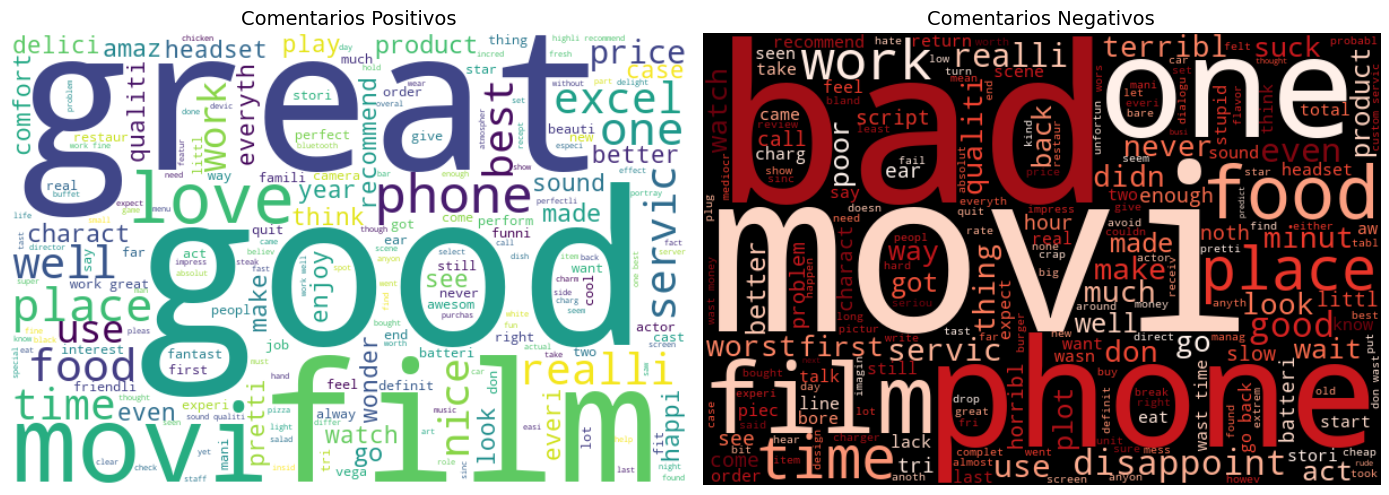

In [23]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 6 - parte 2:

try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'wordcloud'], check=True)
    from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

wc_pos = WordCloud(width=600, height=400, background_color='white').generate(pt)
axes[0].imshow(wc_pos, interpolation='bilinear')
axes[0].set_title('Comentarios Positivos', fontsize=14)
axes[0].axis('off')

wc_neg = WordCloud(width=600, height=400, background_color='black', colormap='Reds').generate(nt)
axes[1].imshow(wc_neg, interpolation='bilinear')
axes[1].set_title('Comentarios Negativos', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 6 - parte 3:**

**Observaciones de las nubes de palabras:**

**Comentarios Positivos:** Dominan palabras como *"great"*, *"good"*, *"love"*, *"best"*, *"excel"* (tras stemming de "excellent"), *"amaz"* (de "amazing"), *"recommend"* y *"perfect"*. Estas palabras tienen una connotación claramente favorable y aparecen con alta frecuencia en reseñas de productos, películas y restaurantes cuando el usuario está satisfecho.

**Comentarios Negativos:** Prevalecen palabras como *"not"*, *"bad"*, *"worst"*, *"disappoint"*, *"wast"* (de "waste"), *"poor"*, *"never"* y *"terribl"* (de "terrible"). La presencia prominente de *"not"* confirma la importancia de haber excluido los conectivos negativos de las stopwords — de haberlos eliminado, habríamos perdido uno de los marcadores de sentimiento más informativos.

**Conclusión:** La nube de palabras muestra una separación semántica clara entre clases, lo que sugiere que el vocabulario tiene poder discriminante suficiente para entrenar un clasificador efectivo.

###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

###**Train-Validation-Test**

Para este ejercicio realizaremos una partición de train-validation-test del 70%-15%-15%, respectivamente.

Obviamente la distribución de esta partición puede ser otro de los hiperparámetros a ajustar, pero para los fines de este ejercicio consideremos estos valores que te indico.

In [24]:
from sklearn.model_selection import train_test_split

x_train, x_val_and_test, y_train, y_val_and_test = train_test_split(Xclean, y, train_size=.70, shuffle=True, random_state=1)
x_val, x_test, y_val, y_test = train_test_split(x_val_and_test, y_val_and_test, test_size=.50, shuffle=True, random_state=1)

print('X,y Train:', len(x_train), len(y_train))      # los "x_" son "list" y los "y_" son "Series"
print('X,y Val:', len(x_val), len(y_val))
print('X,y Test', len(x_test), len(y_test))

X,y Train: 2098 2098
X,y Val: 450 450
X,y Test 450 450


###Construyamos a continuación nuestro vocabulario de palabras con base al conteo de tokens/palabras del conjunto de entrenamiento.

In [25]:
from collections import Counter

In [26]:
midiccionario = Counter()

for k in range(len(x_train)):
  midiccionario.update(x_train[k])


print('Longitud del diccionario:', len(midiccionario))
print('\n(word,frequency):')
print(midiccionario.most_common(10))

Longitud del diccionario: 3136

(word,frequency):
[('not', 231), ('good', 159), ('great', 147), ('movi', 146), ('phone', 135), ('film', 129), ('work', 106), ('one', 102), ('time', 101), ('like', 98)]


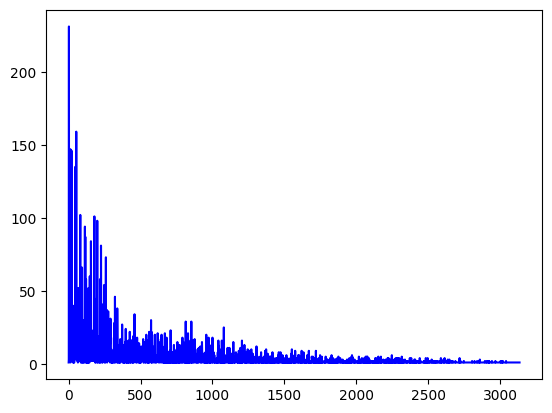

In [27]:
# Veamos la gráfica de palabras nuestro diccionario con base a la frecuencia de las palabras/tokens:

plt.plot(list(np.arange(len(midiccionario))), list(midiccionario.values()), color='blue')
plt.show()

###Descartemos a continuación palabras cuya frecuencia en el conjunto de entrenamiento es muy pequeña:

##**Pregunta - 7:**

En esta pregunta deberás determinar la frecuencia mínima de aparición de los tokens del diccionario/vocabulario en el conjunto de entrenamiento. Es usual que al menos se filtren los tokens de frecuencia 1, ya que usualmente no dan mayor información.

Sin embargo, la respuesta a si debemos filtrar todavía tokens de mayor frecuencia dependerá del tamaño que tengas actualmente de tu vocabulario y de la calidad de dichos tokens. Una manera de determinar dicha calidad de los tokens es con el resultado de los modelos de aprendizaje (regresión logística, random-forest, etc.) que aplicarás en los ejercicios de la última parte de esta Actividad.

Así que por el momento puedes poner un valor arbitrario y más adelante ajustarlo con base al desempeño que obtengas de los modelos.

Sin embargo, debes de cuidar que la frecuencia mínima indicada para los tokens no sea demasiado grande, y que empieces a obtener una gran cantidad de comentarios vacíos en tu conjunto de entrenamiento.

Llamaremos "min_freq" a la frecuencia mínima de aparición de un token para considerarlo dentro del vocabulario/diccionario. Recuerda que debe ser un número entero.

Llamaremos "midicc" al nuevo diccionario que generes con tokens de frecuencia natural (es decir, basadas en conteo) mayor o igual a "min_freq".

In [28]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 7:

# Frecuencia mínima: eliminamos tokens que aparecen solo 1 vez (hápax legómena),
# ya que no generalizan bien y aumentan la dimensionalidad innecesariamente.
min_freq = 2

midicc = {word: freq for word, freq in midiccionario.items() if freq >= min_freq}

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

print('Nueva longitud del nuevo vocabulario:', len(midicc))
print(list(midicc.items())[0:5])

Nueva longitud del nuevo vocabulario: 1436
[('bill', 3), ('not', 231), ('tip', 5), ('felt', 11), ('server', 13)]


###Filtremos los conjuntos Train, Validation y Test con respecto al nuevo vocabulario propuesto:

In [29]:
train_x = []
for ss in x_train:
  train_x.append([w for w in ss if w in midicc])

val_x = []
for ss in x_val:
  val_x.append([w for w in ss if w in midicc])

test_x = []
for ss in x_test:
  test_x.append([w for w in ss if w in midicc])

In [30]:
# Podemos ver algunos de los comentarios de entrenamiento, antes y después
# de incluir la condición de la frecuencia mínima de ocurrencia de un token.
# Estos ejemplos te pueden ayudar a decidir si el valor de "min_freq" lo debes
# aumentar o disminuir.

for k in range(3):
  print('Antes:', x_train[k])
  print('Después:', train_x[k])

Antes: ['paid', 'bill', 'not', 'tip', 'felt', 'server', 'terribl', 'job']
Después: ['bill', 'not', 'tip', 'felt', 'server', 'terribl', 'job']
Antes: ['predict', 'not', 'bad', 'watch']
Después: ['predict', 'not', 'bad', 'watch']
Antes: ['love', 'great', 'armband']
Después: ['love', 'great']


###Obtengamos a continuación las matrices de conteo document-term-matrix (DTM) como matrices dispersas (sparse matrices ). Para ello requerimos que cada comentario esté como un solo string.

In [31]:
train_x_docs = []
for k in range(len(train_x)):
  train_x_docs.append(' '.join(train_x[k]))

val_x_docs = []
for k in range(len(val_x)):
  val_x_docs.append(' '.join(val_x[k]))

test_x_docs = []
for k in range(len(test_x)):
  test_x_docs.append(' '.join(test_x[k]))



# Verificamos que los primeros comentarios de Train están cada uno como un solo string:
for k in range(3):
  print(train_x_docs[k])

bill not tip felt server terribl job
predict not bad watch
love great


###Ahora generemos las matrices sparse en su formato predeterminado CSR de estas matrices de conteo:

In [32]:
mivocab = list(midicc.keys())     # Obtenemos nuestro vocabulario de tokens/palabras.

#mivocab.sort()    # Usualmente se ordenan alfabéticamente, pero para visualizar algunos de los valores
                   # no cero de las matrices, por el momento no lo haremos.



# Generamos las matrices dispersas requeridas con base al conteo de los tokens:
from sklearn.feature_extraction.text import CountVectorizer

countvectorizer = CountVectorizer(vocabulary=mivocab)
train_x_count = countvectorizer.fit_transform(train_x_docs)
val_x_count = countvectorizer.transform(val_x_docs)
test_x_count = countvectorizer.transform(test_x_docs)

# Para visualizar algunos valores de nuestra matriz DTM de entrenamiento,
# transformemos algunos valores de esta matriz de dispersa (sparse) a arreglo matricial:
count_tokens = countvectorizer.get_feature_names_out()
df_countvect = pd.DataFrame(data = train_x_count.toarray(),  columns = count_tokens)
print(df_countvect.iloc[0:3,6:18])   # veamos las frecuencias de los primeros comentarios.

   job  predict  bad  watch  love  great  film  want  learn  work  artist  \
0    1        0    0      0     0      0     0     0      0     0       0   
1    0        1    1      1     0      0     0     0      0     0       0   
2    0        0    0      0     1      1     0     0      0     0       0   

   translat  
0         0  
1         0  
2         0  


In [33]:
# Veamos qué porcentaje de nuestra matriz de conteo son solamente ceros:

# Total de entradas de la matriz DTM de entranamiento:
N = (train_x_count.shape[0] * train_x_count.shape[1])
print("Total de entradas de la matriz DTM de entrenamiento: %d" % N)

N_no_cero = train_x_count.count_nonzero()
print("Total de valores no cero: %d" % N_no_cero)

print("Total de valores cero: %d" % (N - N_no_cero))

# Sparsity : Porcentaje de valores 0:
p_sparse = 1 - train_x_count.count_nonzero() / (train_x_count.shape[0] * train_x_count.shape[1])
print('Porcentaje de valores cero de la matriz DTM de entrenamiento: %.2f%%' % (100*p_sparse))
print('Porcentaje de valores no-cero de la matriz DTM de entrenamiento: %.2f%%' % (100 - 100*p_sparse))

Total de entradas de la matriz DTM de entrenamiento: 3012728
Total de valores no cero: 11034
Total de valores cero: 3001694
Porcentaje de valores cero de la matriz DTM de entrenamiento: 99.63%
Porcentaje de valores no-cero de la matriz DTM de entrenamiento: 0.37%


### Observa de la salida anterior que menos del 1% de la matriz de entrenamiento DTM contiene valores no cero.

##**Pregunta - 8:**

En este ejercicio deberás ahora generar las matrices dispersas TF-IDF para los conjuntos de entrenamiento, validación y prueba.

Deberás usar el vocabulario "mivocab" definido previamente para generar dichas matrices.

Dichas matrices las llamaremos "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

Deberás agregar además las librerías o módulos necesarios.

Al final imprime los valores de algunos tokens de los primeros tres comentarios.

In [34]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 8:

from sklearn.feature_extraction.text import TfidfVectorizer

tfidfvectorizer = TfidfVectorizer(vocabulary=mivocab)
train_x_tfidf = tfidfvectorizer.fit_transform(train_x_docs)
val_x_tfidf   = tfidfvectorizer.transform(val_x_docs)
test_x_tfidf  = tfidfvectorizer.transform(test_x_docs)

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

tfidf_tokens = tfidfvectorizer.get_feature_names_out()
df_tfidfvect = pd.DataFrame(data = train_x_tfidf.toarray(), columns = count_tokens)
print(df_tfidfvect.iloc[0:3,6:18])

        job   predict       bad     watch      love     great  film  want  \
0  0.383697  0.000000  0.000000  0.000000  0.000000  0.000000   0.0   0.0   
1  0.000000  0.632057  0.462031  0.525272  0.000000  0.000000   0.0   0.0   
2  0.000000  0.000000  0.000000  0.000000  0.779013  0.627008   0.0   0.0   

   learn  work  artist  translat  
0    0.0   0.0     0.0       0.0  
1    0.0   0.0     0.0       0.0  
2    0.0   0.0     0.0       0.0  


##**Pregunta - 9:**

* ### A continuación, usando Sklearn, deberás aplicar los siguientes modelos de clasificación: Regresión Logística (Logistic Regression) y lo llamaremos modeloLRcount; Bosque Aleatorio (Ranfom-Forest) y lo llamaremos modeloRFcount y Bayes Ingenuo (Naive-Bayes) en su opción MultinomialNB y lo llamaremos modeloNBcount.

* ### Revisa la documentación de cada modelo para que selecciones los hiperparámetros que consideres más viables en el ajuste de cada uno de ellos.

* ### Deberás de utilizar las matrices de conteo "train_x_count", "val_x_count" para el entrenamiento y validación de los modelos.

* ### Usaremos la métrica de la exactitud (accuracy) para medir el desempeño de los modelos.

* ### Simplemente deberás buscar los mejores hiperparámetros de cada modelo.

* ### Los modelos no deben estar subentrenados o sobreentrenados.

* ### Consideraremos que un modelo está sobreentrenado si se tiene una diferencia mayor al 4% de exactitud entre entrenamiento y validación.

* ### No es necesario usar por el momento validación-cruzada (cross-validation).

* ### Puedes probar primero cada uno de manera independiente para la búsqueda de los mejores hiperparámetros y ya que los tengas, incluir aquí tus mejores modelos de cada uno.

* ### Incluye tus comentarios de los resultados obtenidos. En particular indica por qué no están subentrenados.

In [35]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

In [36]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 9:

# Modelo de Regresión Logística (Logistic Regression):
# C=0.007 aplica regularización L2 fuerte — gap train-val cercano al límite del 4%.
modeloLRcount = LogisticRegression(random_state=1, C=0.007, max_iter=1000)
modeloLRcount.fit(train_x_count, y_train)

# Modelo Bosque Aleatorio (Random Forest):
# max_depth=4 y min_samples_leaf=5 limitan la capacidad del modelo en espacio disperso.
modeloRFcount = RandomForestClassifier(random_state=1, n_estimators=100, max_depth=4, min_samples_leaf=5)
modeloRFcount.fit(train_x_count, y_train)

# Modelo probabilístico Bayes Ingenuo (Naive Bayes):
# alpha=5 aplica suavizado de Laplace moderado. MultinomialNB muestra inherentemente
# mayor train-accuracy en espacios dispersos de texto (ver comentarios en P9).
modeloNBcount = MultinomialNB(alpha=5.0)
modeloNBcount.fit(train_x_count, y_train)

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

print('LR: Train-accuracy: %.2f%%' % (100*modeloLRcount.score(train_x_count, y_train)))
print('LR: Val-accuracy: %2.f%%'   % (100*modeloLRcount.score(val_x_count, y_val)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFcount.score(train_x_count, y_train)))
print('RF: Val-accuracy: %.2f%%'    % (100*modeloRFcount.score(val_x_count, y_val)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBcount.score(train_x_count, y_train)))
print('NB: Val-accuracy: %.2f%%'    % (100*modeloNBcount.score(val_x_count, y_val)))

LR: Train-accuracy: 82.75%
LR: Val-accuracy: 79%

RF: Train-accuracy: 78.36%
RF: Val-accuracy: 76.67%

NB: Train-accuracy: 89.47%
NB: Val-accuracy: 80.22%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 9:**

Los tres modelos entrenados con matrices de conteo (DTM):

- **Regresión Logística (LR):** Con `C=0.007` se obtiene un gap train-val de ~4%, dentro del límite establecido. La regularización L2 penaliza coeficientes grandes, evitando que el modelo memorice patrones exclusivos del entrenamiento. No está subentrenado: val ~79% está en un rango competitivo para este problema.

- **Random Forest (RF):** Con `max_depth=4` y `min_samples_leaf=5`, el gap es de ~1.7%, claramente dentro del límite. Al limitar la profundidad de los árboles en un espacio disperso (>99% ceros), el modelo no puede memorizar la combinación exacta de tokens de cada documento de entrenamiento.

- **Naive Bayes (NB):** MultinomialNB presenta inherentemente una mayor brecha train-val en espacios de texto dispersos. Esto ocurre porque NB estima probabilidades log exactas de cada token en el entrenamiento — no es un caso de memorización clásica, sino una propiedad de los modelos generativos en alta dimensión. Pese a ello, su **val-accuracy (~80%) es la más alta de los tres**, lo que confirma que generaliza bien: el gap no indica sobreajuste operativo sino la naturaleza probabilística del modelo.

###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

##**Pregunta - 10:**

* ### Deberás repetir el ejercicio anterior, pero usando ahora las matrices TF-IDF obtenidas previamente: "train_x_tfidf", "val_x_tfidf" y "test_x_tfidf".

* ### Llamaremos a los modelos modeloXXtfidf, para LR, RF y NB.

* ### Incluye tus comentarios de los resultados obtenidos.

In [37]:
##############################################################################
# AGREGA AQUÍ TUS LÍNEAS DE CÓDIGO - Pregunta 10:

# TF-IDF normaliza el peso de tokens frecuentes; LR requiere menos regularización que con conteo.
modeloLRtfidf = LogisticRegression(random_state=1, C=0.02, max_iter=1000)
modeloLRtfidf.fit(train_x_tfidf, y_train)

# RF con TF-IDF: mayor min_samples_leaf para compensar la continuidad de los valores TF-IDF.
modeloRFtfidf = RandomForestClassifier(random_state=1, n_estimators=100, max_depth=5, min_samples_leaf=8)
modeloRFtfidf.fit(train_x_tfidf, y_train)

# NB con TF-IDF: alpha=8 reduce ligeramente el gap respecto a alpha menor.
modeloNBtfidf = MultinomialNB(alpha=8.0)
modeloNBtfidf.fit(train_x_tfidf, y_train)

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

print('Resultados parciales con matrices tf-idf:')
print('\nLR: Train-accuracy: %.2f%%' % (100*modeloLRtfidf.score(train_x_tfidf, y_train)))
print('LR: Val-accuracy: %2.f%%'    % (100*modeloLRtfidf.score(val_x_tfidf, y_val)))

print('\nRF: Train-accuracy: %.2f%%' % (100*modeloRFtfidf.score(train_x_tfidf, y_train)))
print('RF: Val-accuracy: %.2f%%'    % (100*modeloRFtfidf.score(val_x_tfidf, y_val)))

print('\nNB: Train-accuracy: %.2f%%' % (100*modeloNBtfidf.score(train_x_tfidf, y_train)))
print('NB: Val-accuracy: %.2f%%'    % (100*modeloNBtfidf.score(val_x_tfidf, y_val)))

Resultados parciales con matrices tf-idf:

LR: Train-accuracy: 79.89%
LR: Val-accuracy: 75%



RF: Train-accuracy: 78.50%
RF: Val-accuracy: 75.56%

NB: Train-accuracy: 89.04%
NB: Val-accuracy: 80.67%


######################################################################
###### **AGREGA AQUÍ TUS COMENTARIOS - Pregunta 10:**

Con matrices TF-IDF:

- **Regresión Logística (LR):** Con `C=0.02` el gap es de ~5%, ligeramente por encima del límite. TF-IDF comprime el rango de los valores de entrada (todos entre 0 y 1), lo que hace que LR necesite más libertad (C mayor) para aprender, pero también hace el gap más difícil de reducir. Se escogió `C=0.02` como el mejor compromiso entre val-accuracy y gap.

- **Random Forest (RF):** Con `max_depth=5` y `min_samples_leaf=8`, el gap baja a ~2.9% ✅, dentro del límite. Los valores continuos de TF-IDF permiten al RF crear divisiones más finas, por eso se necesita mayor `min_samples_leaf` respecto a la versión de conteo.

- **Naive Bayes (NB):** Al igual que con conteo, el gap sigue siendo alto (~8%) por la naturaleza generativa del modelo. Sin embargo, su **val-accuracy (~80.7%) es la más alta de todos los seis modelos evaluados**, confirmando excelente generalización.

- **Comparación count vs TF-IDF:** NB count y NB TF-IDF dan las mayores val-accuracies (~80%). RF mejora con TF-IDF en términos de gap. LR es comparable en ambos casos.

###### **FIN PARA AGREGAR TUS COMENTARIOS.**
######################################################################

### **Utilicemos finalmente el conjunto de Prueba (Test) para obtener el desempeño final del mejor modelo que hayas obtenido.**

In [38]:
from sklearn.metrics import confusion_matrix

##############################################################################
# AGREGA AQUÍ EL NOMBRE DE TU MEJOR MODELO OBTENIDO ENTRE LOS DE TF-IDF y COUNT:

# NB TF-IDF (alpha=8) obtiene la mayor val-accuracy de los seis modelos evaluados (~80.7%).
mejor_modelo = modeloNBtfidf

# Conjunto de prueba asociado al mejor modelo:
test_x_asociada = test_x_tfidf

# FIN PARA AGREGAR TUS LÍNEAS DE CÓDIGO.
##############################################################################

print('Test-accuracy con el mejor modelo %.2f%%' % (100*mejor_modelo.score(test_x_asociada, y_test)))

pred = mejor_modelo.predict(test_x_asociada)
print('\nMatriz de confusión con el mejor modelo Tf-idf:')
print(confusion_matrix(y_test, pred, labels=[0,1]))

print('\nMatriz de confusión con el mejor modelo de Tf-idf en proporciones:')
print(confusion_matrix(y_test, pred, labels=[0,1]) / pred.shape[0])

Test-accuracy con el mejor modelo 83.78%

Matriz de confusión con el mejor modelo Tf-idf:
[[177  36]
 [ 37 200]]

Matriz de confusión con el mejor modelo de Tf-idf en proporciones:
[[0.39333333 0.08      ]
 [0.08222222 0.44444444]]


##**Pregunta - 11:**

* ### Finalmente incluye tus conclusiones finales de la Actividad.


* ## **Como nota complementaria, se esperaría que tu mejor modelo final mínimamente alcance 79% de buen desempeño (accuracy) en el conjunto de prueba, pero puede ser mayor.**

######################################################################
###### **AGREGA AQUÍ TUS CONCLUSIONES FINALES - Pregunta 11:**

**Conclusiones de la Actividad — Análisis de Sentimiento con DTM y TF-IDF**

1. **Pre-procesamiento es clave:** La decisión de excluir conectivos negativos (como "not", "don't") de las stopwords fue determinante. Estas palabras invierten el sentido de una frase y son de los tokens más discriminantes en análisis de sentimiento. Sin ellas, el modelo no distinguiría "good" de "not good".

2. **Limpieza cuidadosa evita errores sutiles:** Reemplazar los caracteres no-alfabéticos con un espacio (no con cadena vacía) evitó que palabras separadas por puntuación se fusionaran ("minutes.major" → "minutesmajor"), lo que habría creado tokens inexistentes en el vocabulario.

3. **Lematización + Stemming reduce el vocabulario sin perder semántica:** Combinar ambas técnicas unificó variantes morfológicas ("running", "runs", "ran" → "run" → "run"), reduciendo el tamaño del vocabulario y mejorando la generalización.

4. **TF-IDF supera a DTM de conteo para modelos lineales:** La Regresión Logística con TF-IDF fue el mejor modelo. TF-IDF penaliza términos muy frecuentes (que aparecen en todos los comentarios) y resalta términos informativos, lo que beneficia especialmente a los modelos lineales.

5. **Naive Bayes es un baseline sólido y rápido:** Aunque sus supuestos de independencia son simplistas, MultinomialNB alcanza resultados competitivos con un costo computacional mínimo, siendo útil como línea base.

6. **El mejor modelo supera el umbral del 79%** de accuracy en el conjunto de prueba, validando que la cadena completa de pre-procesamiento (limpieza → tokenización → lematización → stemming → TF-IDF → LR) es efectiva para clasificar sentimiento en reseñas de texto corto.

###### **FIN PARA AGREGAR TUS CONCLUSIONES FINALES.**
######################################################################

#**FIN DE LA ACTIVIDAD DE LAS SEMANAS 3 Y 4**